# Actividad 4 — Calidad · MIDAGRI

**Objetivo:** Auditar la calidad del dataset MIDAGRI: detectar nulos, outliers, inconsistencias geograficas y series temporales incompletas. Documentar cada problema con su decision de correccion para la Actividad 5.

**Regla:** Solo se detecta y documenta. No se corrige nada aqui.


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    r = pd.DataFrame({'nulos': nulos, 'pct': pct})
    r = r[r['nulos'] > 0].sort_values('nulos', ascending=False)
    print(f'=== NULOS EN {nombre} ===')
    if len(r) == 0:
        print('  Sin valores nulos.')
    else:
        print(r.to_string())
    print()
    return r

def outliers_iqr(serie, nombre):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < lower) | (serie > upper)
    n_out = mask.sum()
    pct = n_out / len(serie) * 100
    print(f'{nombre}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}')
    print(f'  Limite inferior: {lower:.2f} | Limite superior: {upper:.2f}')
    print(f'  Outliers: {n_out} ({pct:.2f}%)')
    return lower, upper, mask

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos


In [2]:
xl = pd.ExcelFile(SOURCES['midagri'])
dfs = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
print(f'Dataset completo: {df_m.shape}')
print(f'Solo LIMON: {df_limon.shape}')
print(f'Columnas: {df_m.columns.tolist()}')


Dataset completo: (1596748, 10)
Solo LIMON: (40284, 10)
Columnas: ['anho', 'mes', 'COD_UBIGEO', 'Dpto', 'Prov', 'Dist', 'dsc_Cultivo', 'PRODUCCION(t)', 'COSECHA (ha)', 'MTO_PRECCHAC (S/ x kg)']


## 4.1 Auditoria de Nulos


=== NULOS EN MIDAGRI COMPLETO ===
  Sin valores nulos.

=== NULOS EN MIDAGRI LIMON ===
  Sin valores nulos.



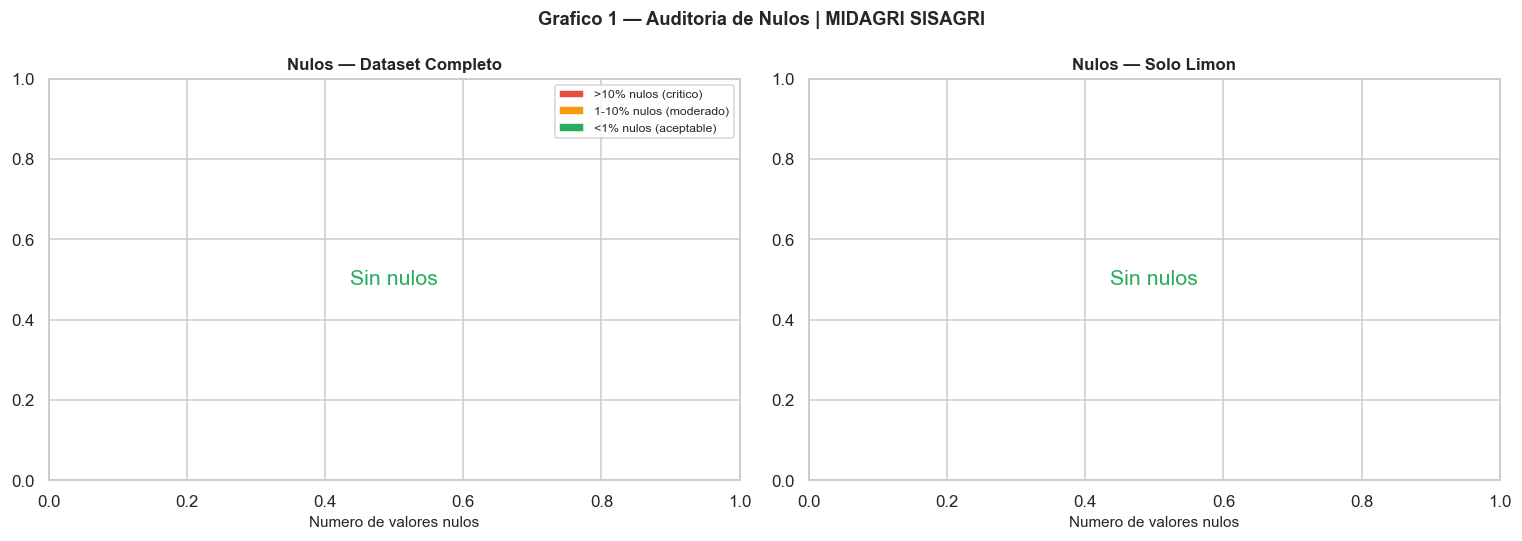

Guardado: pipeline/output/04_calidad/act04_midagri_g1_nulos.png


In [3]:
# Nulos en dataset completo
r_nulos = reporte_nulos(df_m, 'MIDAGRI COMPLETO')
r_nulos_limon = reporte_nulos(df_limon, 'MIDAGRI LIMON')

# Grafico G1: nulos por columna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_plot, titulo in zip(axes,
    [df_m, df_limon],
    ['Dataset Completo', 'Solo Limon']):
    nulos = df_plot.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=True)
    if len(nulos) == 0:
        ax.text(0.5, 0.5, 'Sin nulos', ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='#27ae60')
    else:
        pct = (nulos / len(df_plot) * 100)
        colors = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60' for p in pct]
        ax.barh(nulos.index, nulos.values, color=colors, edgecolor='white')
        for i, (val, p) in enumerate(zip(nulos.values, pct)):
            ax.text(val+0.5, i, f'{val:,} ({p:.1f}%)', va='center', fontsize=8)
    ax.set_xlabel('Numero de valores nulos', fontsize=10)
    ax.set_title(f'Nulos — {titulo}', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(facecolor='#e74c3c', label='>10% nulos (critico)'),
          Patch(facecolor='#f39c12', label='1-10% nulos (moderado)'),
          Patch(facecolor='#27ae60', label='<1% nulos (aceptable)')]
axes[0].legend(handles=legend, fontsize=8)
plt.suptitle('Grafico 1 — Auditoria de Nulos | MIDAGRI SISAGRI',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g1_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Valores nulos en columnas numericas (produccion, precio, cosecha)  
**Magnitud:** Ver tabla de nulos arriba — porcentaje exacto por columna  
**Decision (Actividad 5):** Imputar con la mediana por departamento-mes si < 5%. Eliminar filas si > 20%.


## 4.2 Auditoria de Outliers (IQR)


PRODUCCION(t): Q1=2.00 Q3=15.00 IQR=13.00
  Limite inferior: -17.50 | Limite superior: 34.50
  Outliers: 5924 (14.71%)

MTO_PRECCHAC (S/ x kg): Q1=0.80 Q3=1.55 IQR=0.75
  Limite inferior: -0.32 | Limite superior: 2.67
  Outliers: 2838 (7.04%)

COSECHA (ha): Q1=2.00 Q3=10.00 IQR=8.00
  Limite inferior: -10.00 | Limite superior: 22.00
  Outliers: 387 (15.30%)



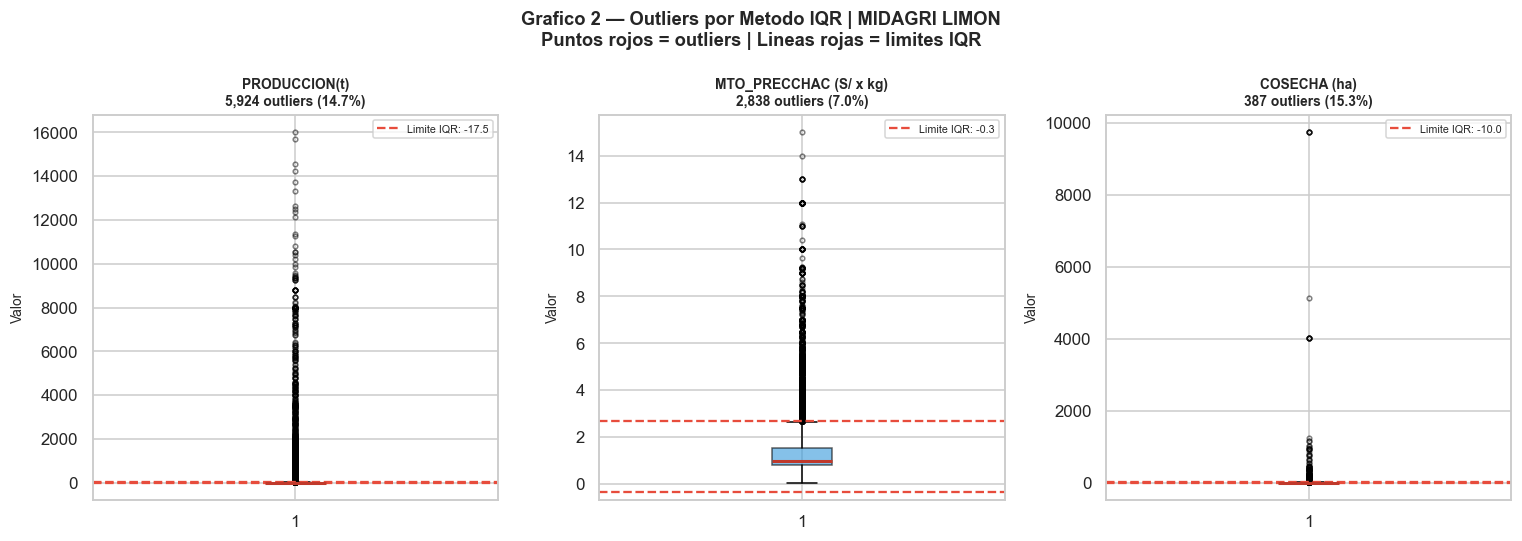

Guardado: pipeline/output/04_calidad/act04_midagri_g2_outliers.png


In [4]:
cols_num = ['PRODUCCION(t)', 'MTO_PRECCHAC (S/ x kg)', 'COSECHA (ha)']
cols_num = [c for c in cols_num if c in df_limon.columns]

resultados_iqr = {}
for col in cols_num:
    serie = df_limon[col].dropna()
    serie = serie[serie > 0]
    lower, upper, mask_out = outliers_iqr(serie, col)
    resultados_iqr[col] = {'lower': lower, 'upper': upper,
                            'n_outliers': mask_out.sum(),
                            'pct': mask_out.sum()/len(serie)*100}
    print()

# Grafico G2: boxplots con outliers
fig, axes = plt.subplots(1, len(cols_num), figsize=(14, 5))
if len(cols_num) == 1: axes = [axes]
for ax, col in zip(axes, cols_num):
    data = df_limon[col].dropna()
    data = data[data > 0]
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#c0392b', linewidth=2),
                    flierprops=dict(marker='o', color='#e74c3c',
                                    markersize=3, alpha=0.5))
    info = resultados_iqr[col]
    ax.axhline(info['lower'], color='#e74c3c', linestyle='--',
               linewidth=1.5, label=f'Limite IQR: {info["lower"]:.1f}')
    ax.axhline(info['upper'], color='#e74c3c', linestyle='--', linewidth=1.5)
    ax.set_title(f'{col}\n{info["n_outliers"]:,} outliers ({info["pct"]:.1f}%)',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Grafico 2 — Outliers por Metodo IQR | MIDAGRI LIMON\n'
             'Puntos rojos = outliers | Lineas rojas = limites IQR',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g2_outliers.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Outliers extremos en produccion, precio y cosecha  
**Magnitud:** Ver tabla IQR arriba — numero y porcentaje exacto por variable  
**Decision (Actividad 5):** Aplicar filtro IQR (1.5x) en la Actividad 5. Registrar cuantos registros se eliminan.


## 4.3 Cobertura Temporal por Departamento


Total meses en el dataset: 116
Departamentos con cobertura completa: 14
Departamentos con cobertura incompleta: 9

Departamentos incompletos:
  LIMA: 20/116 meses (17%)
  AREQUIPA: 23/116 meses (20%)
  PASCO: 28/116 meses (24%)
  MOQUEGUA: 52/116 meses (45%)
  PUNO: 52/116 meses (45%)
  HUANCAVELICA: 96/116 meses (83%)
  ICA: 100/116 meses (86%)
  CUSCO: 114/116 meses (98%)
  AYACUCHO: 114/116 meses (98%)


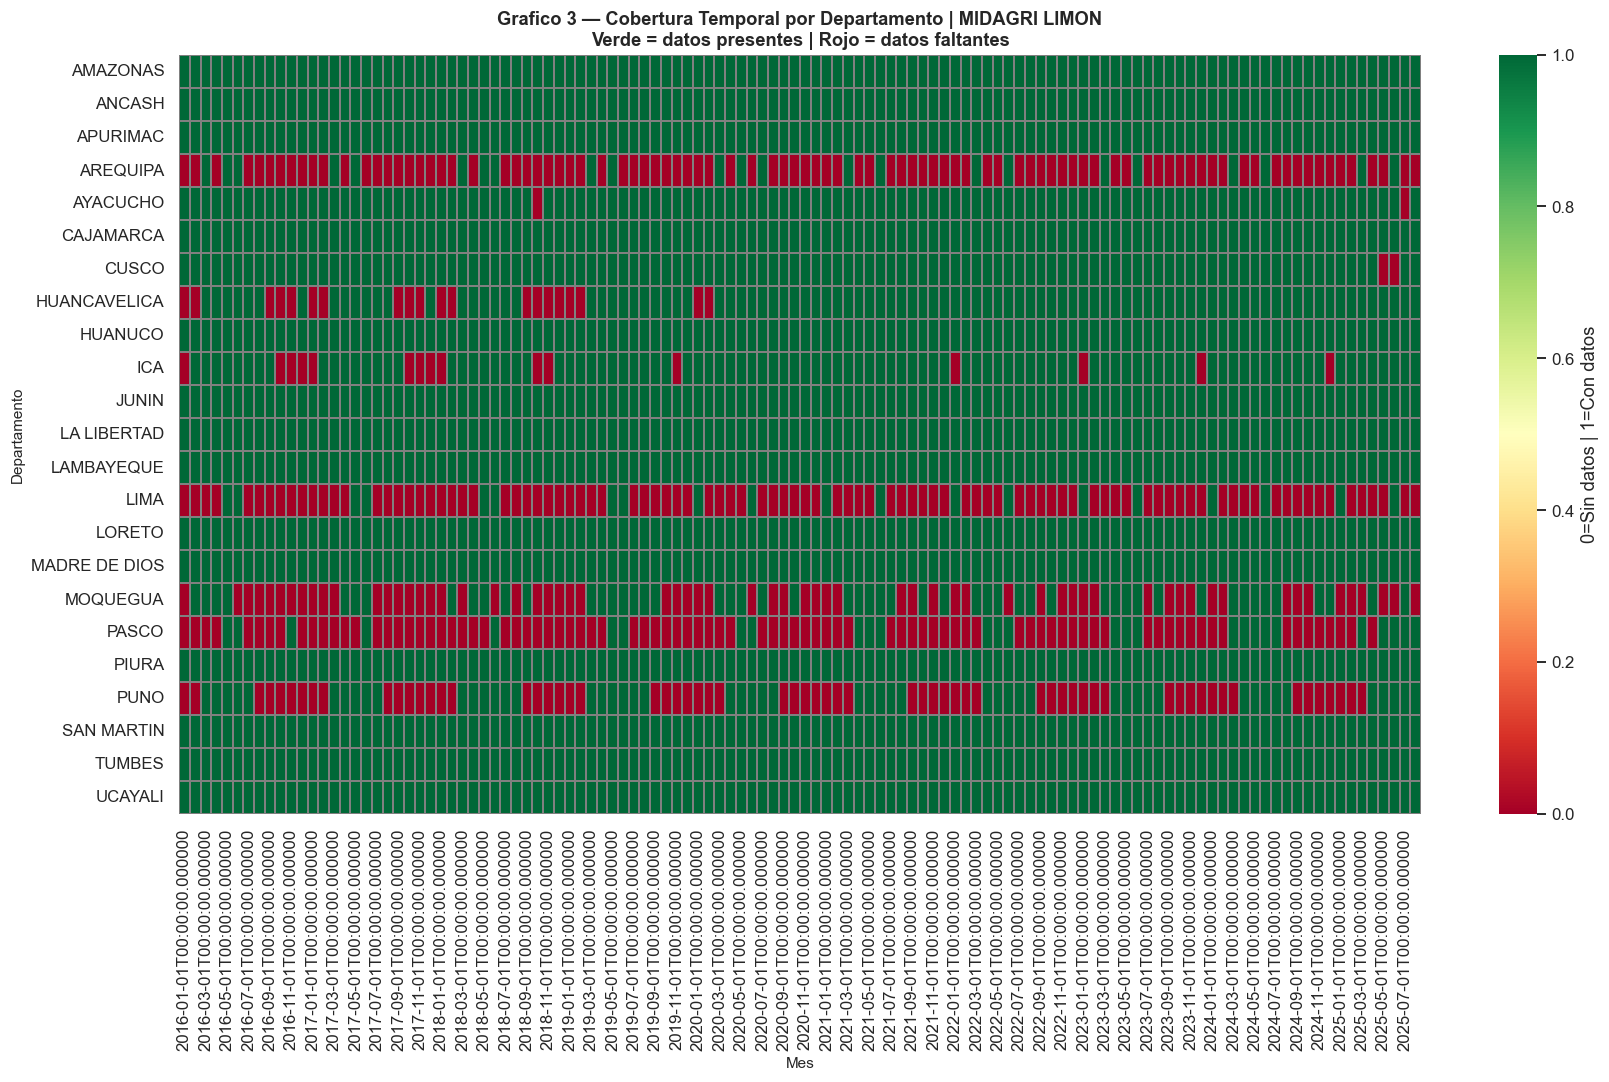

Guardado: pipeline/output/04_calidad/act04_midagri_g3_cobertura.png


In [5]:
# Verificar si hay meses faltantes por departamento
df_limon['fecha_mes'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
cobertura = df_limon.groupby(['Dpto','fecha_mes']).size().unstack(fill_value=0)
cobertura_bool = (cobertura > 0).astype(int)

# Departamentos con cobertura incompleta
total_meses = cobertura_bool.shape[1]
meses_por_dpto = cobertura_bool.sum(axis=1)
dptos_incompletos = meses_por_dpto[meses_por_dpto < total_meses]
print(f'Total meses en el dataset: {total_meses}')
print(f'Departamentos con cobertura completa: {(meses_por_dpto == total_meses).sum()}')
print(f'Departamentos con cobertura incompleta: {len(dptos_incompletos)}')
if len(dptos_incompletos) > 0:
    print()
    print('Departamentos incompletos:')
    for dpto, n in dptos_incompletos.sort_values().items():
        print(f'  {dpto}: {n}/{total_meses} meses ({n/total_meses*100:.0f}%)')

# Grafico G3: heatmap cobertura
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(cobertura_bool, cmap='RdYlGn', ax=ax,
            cbar_kws={'label': '0=Sin datos | 1=Con datos'},
            linewidths=0.1, linecolor='gray')
ax.set_title('Grafico 3 — Cobertura Temporal por Departamento | MIDAGRI LIMON\n'
             'Verde = datos presentes | Rojo = datos faltantes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes', fontsize=10)
ax.set_ylabel('Departamento', fontsize=10)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g3_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Departamentos con series temporales incompletas (meses faltantes)  
**Magnitud:** Ver tabla de departamentos incompletos arriba  
**Decision (Actividad 5):** En la Actividad 5 se evaluara excluir departamentos con < 80% de cobertura temporal.


## 4.4 Inconsistencias en Nombres Geograficos


In [6]:
# Detectar variaciones en nombres de departamentos y provincias
print('=== VARIACIONES EN NOMBRES DE DEPARTAMENTOS ===')
dptos_unicos = sorted(df_m['Dpto'].dropna().unique().tolist())
print(f'Total departamentos unicos: {len(dptos_unicos)}')

# Agrupar por nombre normalizado para detectar variantes
df_m['Dpto_norm'] = df_m['Dpto'].apply(normalizar)
variantes = df_m.groupby('Dpto_norm')['Dpto'].unique()
variantes_multiples = variantes[variantes.apply(len) > 1]

if len(variantes_multiples) > 0:
    print(f'Departamentos con variantes de nombre: {len(variantes_multiples)}')
    for norm, variants in variantes_multiples.items():
        print(f'  {norm}: {list(variants)}')
else:
    print('Sin variantes de nombre detectadas en departamentos.')

print()
print('=== VARIACIONES EN NOMBRES DE PROVINCIAS ===')
df_m['Prov_norm'] = df_m['Prov'].apply(normalizar)
variantes_prov = df_m.groupby('Prov_norm')['Prov'].unique()
variantes_prov_mult = variantes_prov[variantes_prov.apply(len) > 1]
print(f'Provincias con variantes de nombre: {len(variantes_prov_mult)}')
if len(variantes_prov_mult) > 0:
    for norm, variants in list(variantes_prov_mult.items())[:10]:
        print(f'  {norm}: {list(variants)}')

# Reporte de calidad MIDAGRI
reporte = [
    'REPORTE DE CALIDAD — MIDAGRI SISAGRI',
    '=' * 60,
    f'Registros totales: {len(df_m):,}',
    f'Registros LIMON: {len(df_limon):,}',
    f'Departamentos unicos: {len(dptos_unicos)}',
    f'Variantes de nombre en dptos: {len(variantes_multiples)}',
    f'Variantes de nombre en provs: {len(variantes_prov_mult)}',
]
for col in cols_num:
    if col in resultados_iqr:
        info = resultados_iqr[col]
        reporte.append(f'Outliers {col}: {info["n_outliers"]:,} ({info["pct"]:.1f}%)')

reporte_txt = '\n'.join(reporte)
print()
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_midagri.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - MIDAGRI] COMPLETADA.')


=== VARIACIONES EN NOMBRES DE DEPARTAMENTOS ===
Total departamentos unicos: 25


Sin variantes de nombre detectadas en departamentos.

=== VARIACIONES EN NOMBRES DE PROVINCIAS ===


Provincias con variantes de nombre: 0

REPORTE DE CALIDAD — MIDAGRI SISAGRI
Registros totales: 1,596,748
Registros LIMON: 40,284
Departamentos unicos: 25
Variantes de nombre en dptos: 0
Variantes de nombre en provs: 0
Outliers PRODUCCION(t): 5,924 (14.7%)
Outliers MTO_PRECCHAC (S/ x kg): 2,838 (7.0%)
Outliers COSECHA (ha): 387 (15.3%)

[ACTIVIDAD 4 - MIDAGRI] COMPLETADA.


### Decision tecnica documentada

**Problema:** Variaciones en nombres geograficos (mayusculas, tildes, abreviaciones)  
**Magnitud:** Ver tabla de variantes arriba  
**Decision (Actividad 5):** En la Actividad 5 se normalizaran todos los nombres a MAYUSCULAS SIN TILDES usando unicodedata.
